# Hetrozygosity
Calculate heterozygosity ratios and visualize them nicely.

## Libraries

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

if os.getcwd().startswith("/home/lakrids"):
    path_prefix = "/home/lakrids/GenomeDK"
else:
    path_prefix = "/faststorage/project/"
    
# define species and username so that the files can be found
group = "Panthera_tigris"
colours = {"Panthera_tigris":"orange",
              "Elephas_maximus":"teal"}


## Data import

In [ ]:
merged_counts_df = pd.read_csv(f"{path_prefix}/megaFauna/sa_megafauna/data/{group}/VCF/snp_counts/merged_counts.txt", sep="\t")
cov_df = pd.read_csv(f"{path_prefix}/megaFauna/sa_megafauna/data/{group}/ref/samples_coverage_stats_filtered.txt", sep="\t")

### Create a merged dataframe

In [3]:
merged_df = merged_counts_df.merge(cov_df[['IND_ID', 'len_covered_raw_A', 'len_covered_raw_X']],
                                  left_on='IND_ID', right_on='IND_ID', how='left')
merged_df

,IND_ID,autosomal,chrX,chrY,chrM,len_covered_raw_A,len_covered_raw_X
0,SAMN20424165,1528846,0,0,0,2267484337,126498095
1,SAMN17816832,616670,12349,0,0,2266902973,127438727
2,SAMN20424166,1563956,0,0,0,2265776446,126985917
3,SAMN02086964,1233240,0,0,0,2264015719,127238349
4,SAMN17816833,1280230,0,0,0,2269118605,127259368
...,...,...,...,...,...,...,...
134,SAMN20424162,1385404,15088,0,0,2265534734,127277285
135,SAMN17816817,1098156,23314,0,0,2268297583,127534696
136,SAMN17816830,1427629,0,0,0,2267825688,126851210
137,SAMN20424163,1410314,0,0,0,2266363960,125735674


## Calculate heterozygosity ratios.
Mostly for autosomes and optionally X. Y Chromosome is missing for now, because i couldn't really calculate the number of SNPs (not sure why).

In [4]:
merged_df['het_autosomal'] = merged_df['autosomal'] / merged_df['len_covered_raw_A']
merged_df['het_chrX'] = merged_df['chrX'] / merged_df['len_covered_raw_X']
merged_df

,IND_ID,autosomal,chrX,chrY,chrM,len_covered_raw_A,len_covered_raw_X,het_autosomal,het_chrX
0,SAMN20424165,1528846,0,0,0,2267484337,126498095,0.000674,0.000000
1,SAMN17816832,616670,12349,0,0,2266902973,127438727,0.000272,0.000097
2,SAMN20424166,1563956,0,0,0,2265776446,126985917,0.000690,0.000000
3,SAMN02086964,1233240,0,0,0,2264015719,127238349,0.000545,0.000000
4,SAMN17816833,1280230,0,0,0,2269118605,127259368,0.000564,0.000000
...,...,...,...,...,...,...,...,...,...
134,SAMN20424162,1385404,15088,0,0,2265534734,127277285,0.000612,0.000119
135,SAMN17816817,1098156,23314,0,0,2268297583,127534696,0.000484,0.000183
136,SAMN17816830,1427629,0,0,0,2267825688,126851210,0.000630,0.000000
137,SAMN20424163,1410314,0,0,0,2266363960,125735674,0.000622,0.000000


## The plot

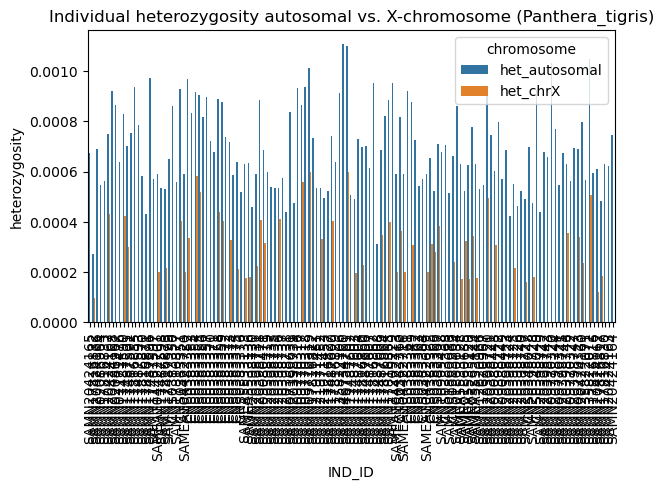

In [ ]:
melted = merged_df.melt(id_vars='IND_ID', 
                     value_vars=['het_autosomal', 'het_chrX'], 
                     var_name='chromosome', value_name='heterozygosity')

sns.barplot(data=melted, x='IND_ID', y='heterozygosity', hue='chromosome')
plt.xticks(rotation=90)
plt.tight_layout()
plt.title(f"Individual heterozygosity autosomal vs. X-chromosome ({group})")
plt.show()

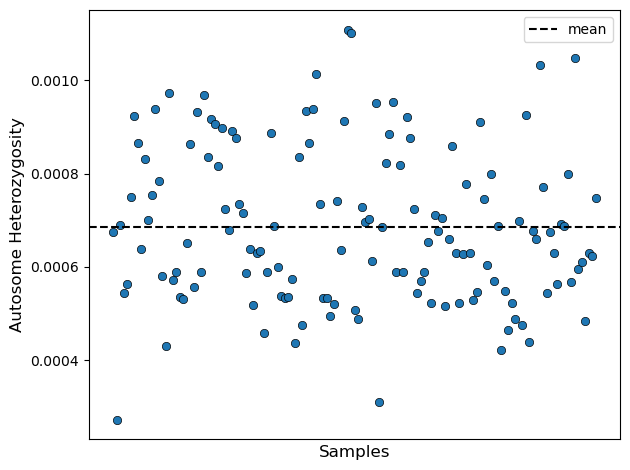

In [24]:
sns.scatterplot(data=merged_df, x='IND_ID', y='het_autosomal', edgecolor='black')
plt.xticks([])
#plt.title(f"Individual autosomal heterozygosity ({species})")

# get mean value
mean_val = merged_df['het_autosomal'].mean()
plt.axhline(mean_val, color='black', linestyle='--', label="mean")
plt.xlabel("Samples", fontsize=12)
plt.ylabel("Autosome Heterozygosity", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

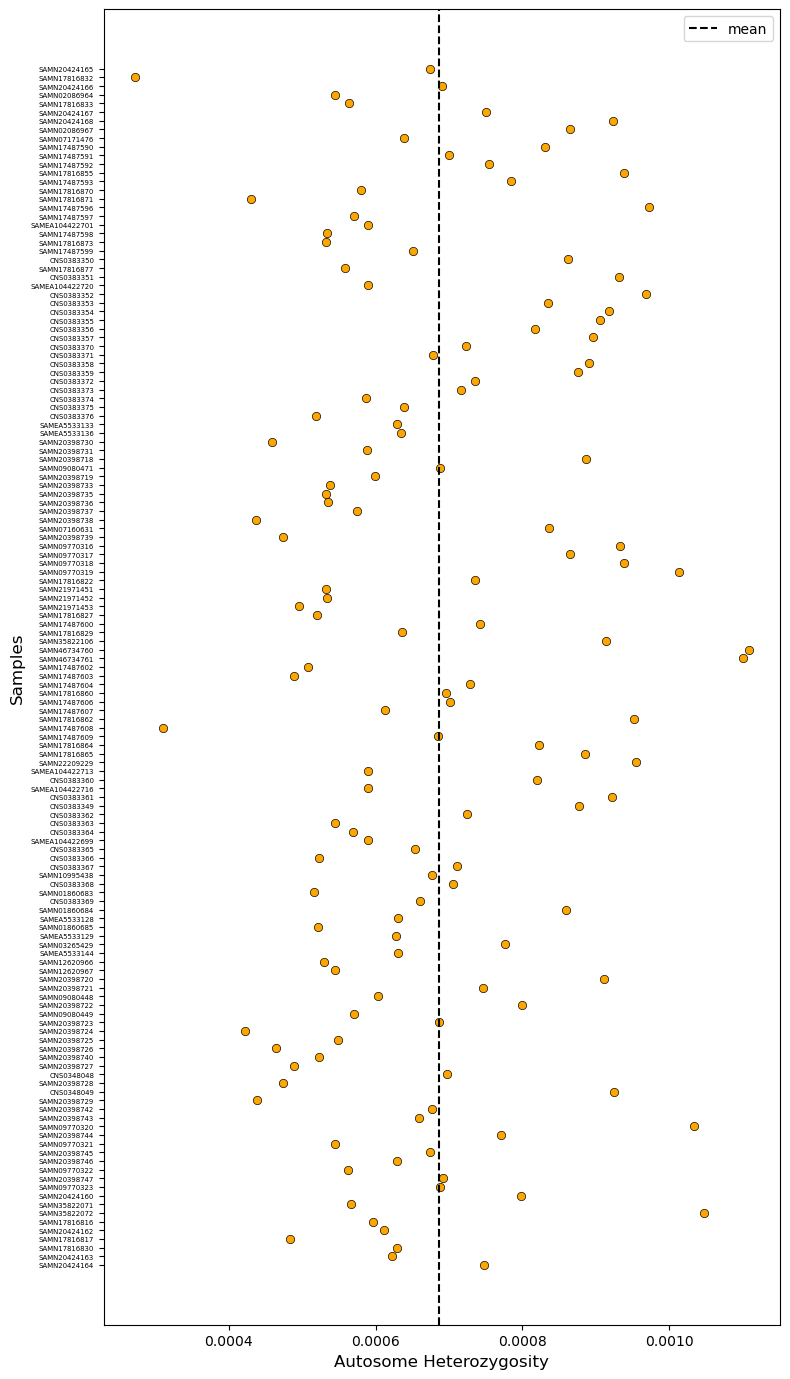

In [ ]:
fig, ax = plt.subplots(figsize=(8, max(6, len(merged_df) * 0.1)))

sns.scatterplot(data=merged_df, x='het_autosomal', y='IND_ID',
                color=colours.get(group), edgecolor='black', ax=ax)

mean_val = merged_df['het_autosomal'].mean()
ax.axvline(mean_val, color='black', linestyle='--', label="mean")

ax.set_ylabel("Samples", fontsize=12)
ax.set_xlabel("Autosome Heterozygosity", fontsize=12)
ax.legend()
plt.yticks(fontsize=5)
plt.tight_layout()
plt.show()

In [7]:
float(merged_df['het_autosomal'].mean())

0.0006683723616536197